# LOAD DATA

In [3]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

import ssl
import certifi

ssl._create_default_https_context = ssl._create_unverified_context

# Load dataset
housing = fetch_california_housing()

# Convert to DataFrame
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df["MedHouseVal"] = housing.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
df.corr()["MedHouseVal"].sort_values(ascending=False)

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64

In [10]:
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


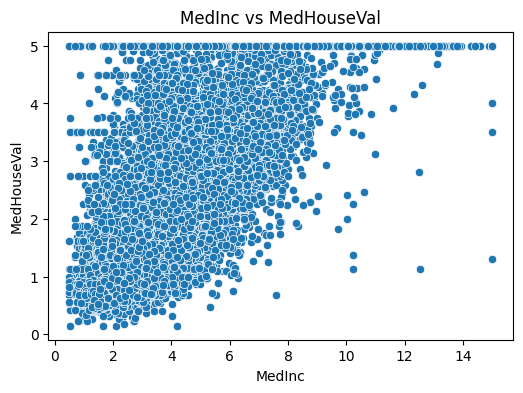

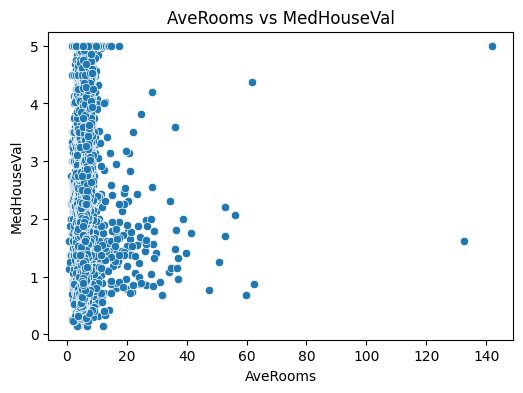

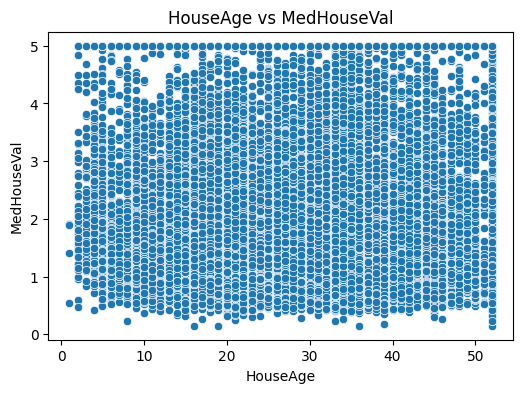

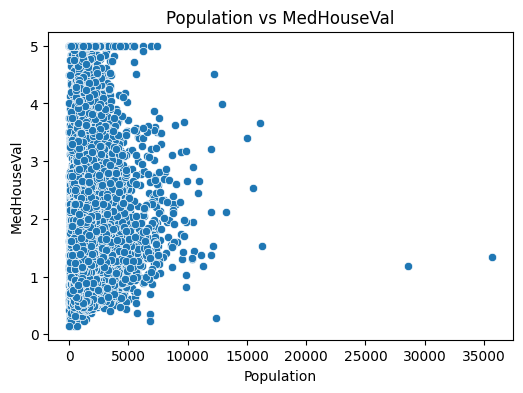

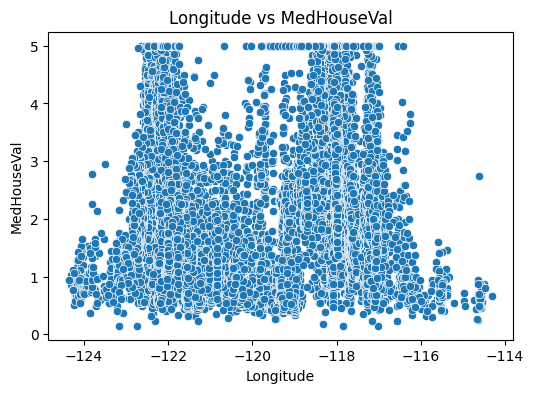

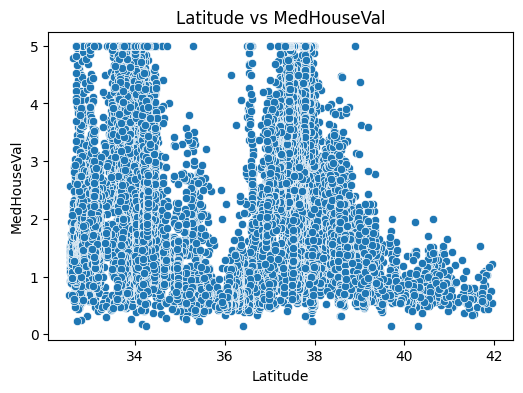

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns


features = ["MedInc", "AveRooms", "HouseAge", "Population", "Longitude", "Latitude"]

for feature in features:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=df[feature], y=df["MedHouseVal"])
    plt.title(f"{feature} vs MedHouseVal")
    plt.show()

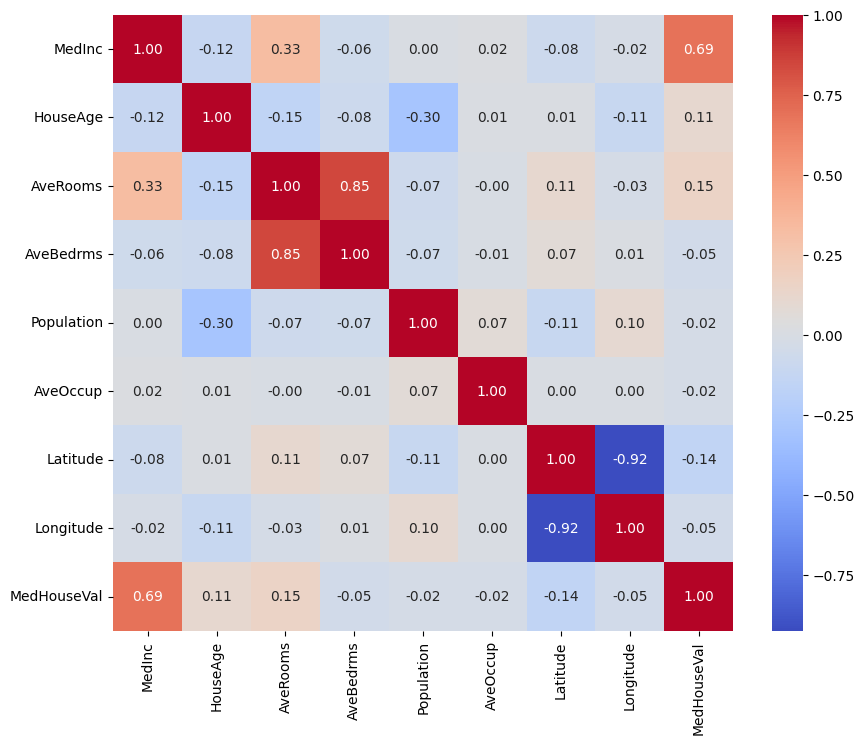

In [16]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = df.drop("MedHouseVal", axis=1)
X_scaled = scaler.fit_transform(X)

y = df["MedHouseVal"].values

In [18]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# Features & target
X = df.drop("MedHouseVal", axis=1).values
y = df["MedHouseVal"].values.reshape(-1, 1)

# Split data into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling (important for gradient descent)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

2026-03-04 21:31:43.126666: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [19]:
# Build model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1, input_shape=(X_train_scaled.shape[1],), activation='linear')
])

# Compile model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
              loss='mse',  # Mean Squared Error
              metrics=['mae'])  # Mean Absolute Error for easier interpretation

/Users/yengsebastian/Documents/tensorflow/venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
history = model.fit(X_train_scaled, y_train, 
                    validation_split=0.2, 
                    epochs=100, 
                    batch_size=32,
                    verbose=1)

Epoch 1/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.8968 - mae: 0.9114 - val_loss: 0.7082 - val_mae: 0.5420
Epoch 2/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7206 - mae: 0.5333 - val_loss: 0.6031 - val_mae: 0.5419
Epoch 3/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5890 - mae: 0.5301 - val_loss: 0.5651 - val_mae: 0.5331
Epoch 4/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5319 - mae: 0.5263 - val_loss: 0.5574 - val_mae: 0.5417
Epoch 5/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5182 - mae: 0.5284 - val_loss: 0.5491 - val_mae: 0.5416
Epoch 6/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5185 - mae: 0.5283 - val_loss: 0.5508 - val_mae: 0.5355
Epoch 7/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.5168 - mae: 0.5282 - val_loss: 0.5463 - val_mae: 0.5418
Epoch 8/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.5219 - mae: 0.5286 - val_loss: 0.5456 - val_mae: 0.5425
Epoch 9/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/

In [21]:
# Evaluate on test data
loss, mae = model.evaluate(X_test_scaled, y_test)
print(f"Test MSE: {loss:.4f}, Test MAE: {mae:.4f}")

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5474 - mae: 0.5410
Test MSE: 0.5474, Test MAE: 0.5410


129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


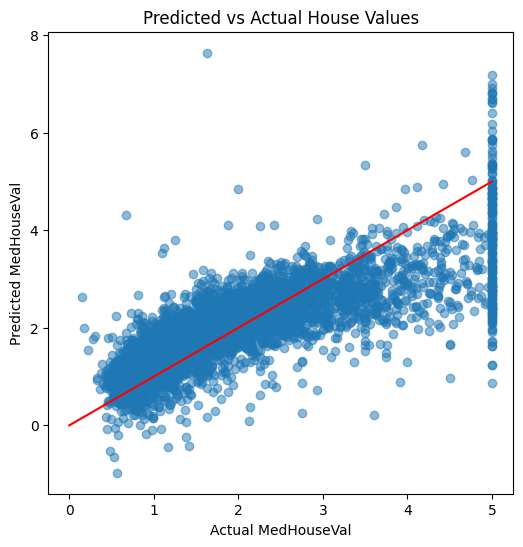

In [22]:
y_pred = model.predict(X_test_scaled)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([0,5],[0,5], 'r')  # perfect prediction line
plt.xlabel("Actual MedHouseVal")
plt.ylabel("Predicted MedHouseVal")
plt.title("Predicted vs Actual House Values")
plt.show()